In [1]:
import torch, torchvision # pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
from sklearn.model_selection import train_test_split, GroupKFold, StratifiedKFold

from PIL import Image
import matplotlib.pyplot as plt
import cv2, os, shutil, glob, json, math, datetime, random, gc, ast
import numpy as np
import pandas as pd
import torch.nn as nn
import seaborn as sns
from time import time
from utils.index import *
from tqdm import tqdm

from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.ops import nms

from torch.utils.data import DataLoader, Dataset
from torch.utils.data.sampler import SequentialSampler

import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2
from utils.Plotter.index import Plotter
pd.set_option('display.max_columns', None)

In [2]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

gc.collect()
print(torch.__version__)              # versão do PyTorch
print(torch.cuda.is_available())      # True se detectou a GPU
print(torch.cuda.get_device_name(0))  # nome da GPU

2.7.1+cu118
True
Quadro P6000


In [3]:
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    np.random.default_rng(seed=seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print('random seed done')


In [4]:
OPTIONS = json.loads(open('../Task/info.json', 'r').read())

# CADA TRIAL DA MESMA RODADA MUDA SO A SEMENTE (INICIALIZACAO, EMBARALHAMENTO E AUGMENTATION);
# OS SPLITS CONTINUAM COM random_state=42, ENTAO O TESTE E O MESMO EM TODOS OS TRIALS
TRIAL = OPTIONS.get('trial', 0)
seed_everything(42 + TRIAL)
OPTIONS


random seed done


{'network': 'standard',
 'dataset': 'dataset_74',
 'img_size': None,
 'lr': 0.001,
 'loss': 'smooth_dice',
 'batch_size': 2,
 'scheduler': 'plateau',
 'dropout': 0.1,
 'num_filters': 8,
 'ema': False,
 'n_trials': 2,
 'epochs': 1,
 'trial': 1}

In [5]:
if OPTIONS.get('network') == 'macnn':
    torch.backends.cudnn.deterministic = False

IMG_SIZE   = OPTIONS.get('img_size')
BATCH_SIZE = OPTIONS.get('batch_size')
IMG_SIZE, BATCH_SIZE

(None, 2)

In [6]:
DATABASE = f'../Dataset/{OPTIONS.get("dataset")}/DataBase.csv'
df       = pd.read_csv(DATABASE)
IMG_SIZE = ast.literal_eval(df['shape'].iloc[0])

OPTIONS['img_size'] = IMG_SIZE
print(f'{DATABASE}: {len(df)} volumes de shape {IMG_SIZE}')
print(df.img_path.iloc[0])
df

../Dataset/dataset_74/DataBase.csv: 220 volumes de shape (128, 128, 128)
/home/grva-mint/Projects/Falhas/Dataset/dataset_74/images/img_0000.npy


,id,img_min,img_max,img_mean,img_std,msk_min,msk_max,shape,img_path,mask_path
0,img_0000.npy,0.0,1.0,0.498273,0.206325,0,1,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
1,img_0001.npy,0.0,1.0,0.498135,0.204917,0,1,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
2,img_0002.npy,0.0,1.0,0.497561,0.203653,0,1,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
3,img_0003.npy,0.0,1.0,0.499910,0.199585,0,1,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
4,img_0004.npy,0.0,1.0,0.499684,0.172918,0,1,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
...,...,...,...,...,...,...,...,...,...,...
215,img_0215.npy,0.0,1.0,0.498193,0.205946,0,1,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
216,img_0216.npy,0.0,1.0,0.498145,0.199423,0,1,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
217,img_0217.npy,0.0,1.0,0.498914,0.203403,0,1,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
218,img_0218.npy,0.0,1.0,0.497858,0.203141,0,1,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...


In [7]:
MULTICLASS = False
classes    = 1
classes

1

img: (np.float32(0.0), np.float32(1.0))
msk: (np.uint8(0), np.uint8(1))


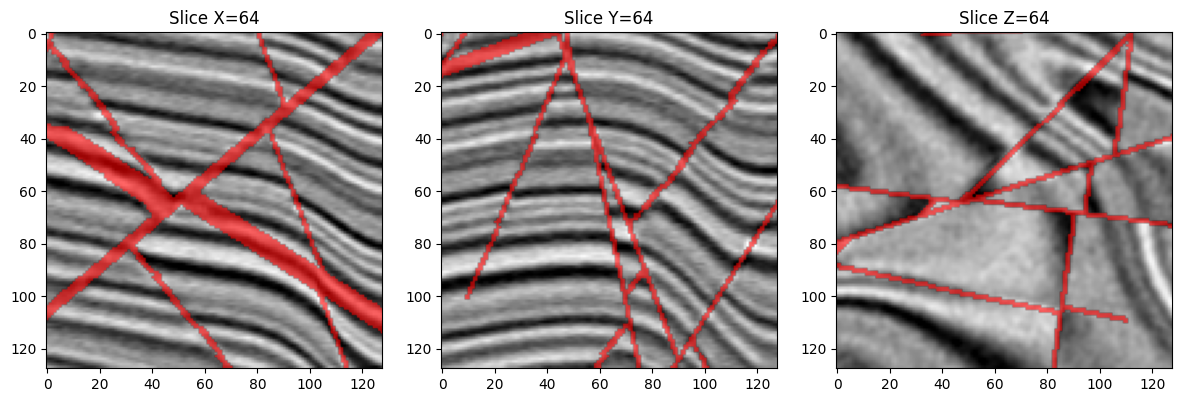

img: (np.float32(0.0), np.float32(1.0))
msk: (np.uint8(0), np.uint8(1))


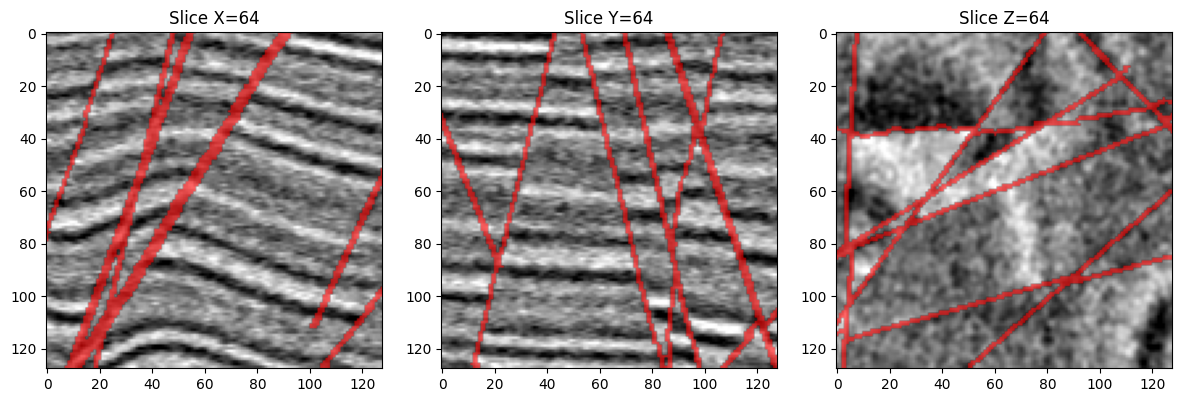

img: (np.float32(0.0), np.float32(1.0))
msk: (np.uint8(0), np.uint8(1))


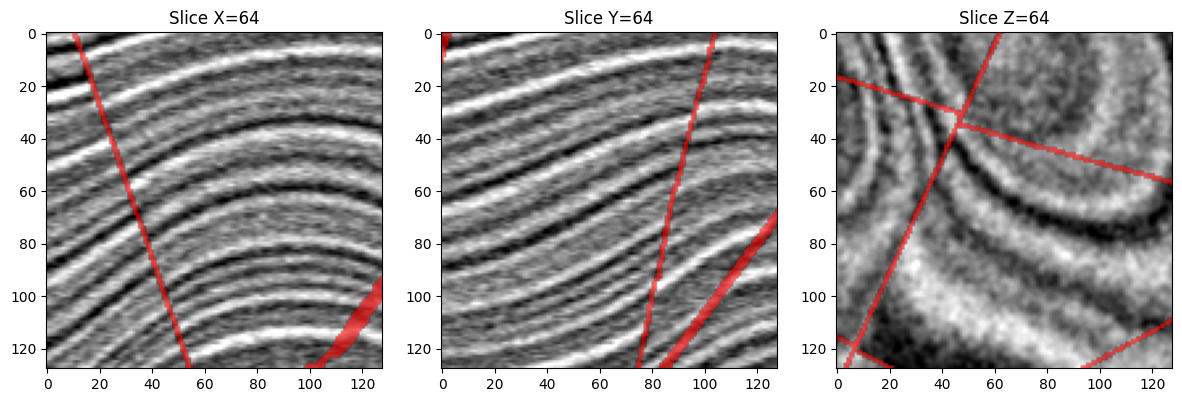

In [8]:
for index in range(3):
    img, msk = np.load(df.iloc[index].img_path), np.load(df.iloc[index].mask_path)
    print(f'img: {np.min(img), np.max(img)}')
    print(f'msk: {np.min(msk), np.max(msk)}')
    showTile(img=img, mask=msk)

# SPLITS DOS DADOS

In [9]:
VAL_SIZE  = 0.045454545454545456
TEST_SIZE = 0.045454545454545456
VAL_SIZE  = VAL_SIZE / (1 - TEST_SIZE)

In [10]:
temp_df, test_df = train_test_split(df, test_size=TEST_SIZE, random_state=42)
train_df, val_df = train_test_split(temp_df, test_size=VAL_SIZE, random_state=42)
del temp_df

OPTIONS['n_images'] = {'total': len(df), 'train': len(train_df), 'val': len(val_df), 'test': len(test_df)}
OPTIONS['n_images']

{'total': 220, 'train': 200, 'val': 10, 'test': 10}

# MODELO

In [11]:
from Network.index import ModelNetwork

In [12]:
model_options = {
    'network': OPTIONS.get('network'),
    'img_size': OPTIONS.get('img_size'),
    'classes': classes,
    'channels': 1,
    'dropout': OPTIONS.get('dropout'),
    'num_filters': OPTIONS.get('num_filters'),
    'lr': OPTIONS.get('lr'),
}

print(model_options)
network = ModelNetwork(**model_options)
network.model

{'network': 'standard', 'img_size': (128, 128, 128), 'classes': 1, 'channels': 1, 'dropout': 0.1, 'num_filters': 8, 'lr': 0.001}


UNet3D(
  (enc_conv1): DoubleConv(
    (double_conv): Sequential(
      (0): Conv3d(1, 8, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (1): BatchNorm3d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv3d(8, 8, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (4): BatchNorm3d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout(p=0.05, inplace=False)
  (enc_conv2): DoubleConv(
    (double_conv): Sequential(
      (0): Conv3d(8, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (1): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (4): BatchNorm3d(16, eps=1e-05, 

In [13]:
network.classes

1

# DATASET

In [14]:
from torch.utils.data import Dataset
from Transforms.index import Compose

In [15]:
class CustomDataset(Dataset):
    def __init__(self, df, multiclass=False, augmentations=None):
        self.df = df.reset_index(drop=True)
        self.multiclass = multiclass
        self.augmentor  = Compose(augmentations) if augmentations else None

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row  = self.df.iloc[index]
        img  = np.load(row.img_path).astype(np.float32)
        mask = np.load(row.mask_path).astype(np.float32)

        if self.augmentor:
            img, mask = self.augmentor(img, mask)

        img_tensor  = torch.tensor(img,  dtype=torch.float32).unsqueeze(0)
        mask_tensor = torch.tensor(mask, dtype=torch.long).unsqueeze(0)
        return (img_tensor, mask_tensor)


trainDataset=CustomDataset(
    df=train_df, 
    multiclass=MULTICLASS,
    augmentations=OPTIONS.get('augmentations')
)

valDataset=CustomDataset(
    df=val_df, 
    multiclass=MULTICLASS
)

testDataset=CustomDataset(
    df=test_df, 
    multiclass=MULTICLASS
)

# DATA LOADER

In [16]:
from torch.utils.data import DataLoader

In [17]:
NUM_WORKERS = 2

trainLoader = DataLoader(
    trainDataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

valLoader = DataLoader(
    valDataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

testLoader = DataLoader(
    testDataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

xTrain Shape:  (128, 128, 128)
yTrain Shape:  (128, 128, 128)
xTrain Range:  (0.0, 1.0)
yTrain Unique: [0 1]


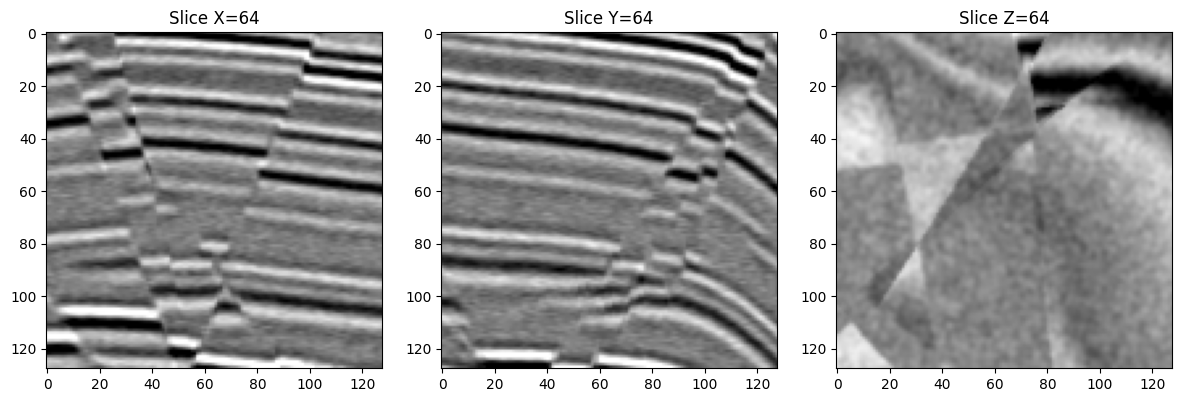

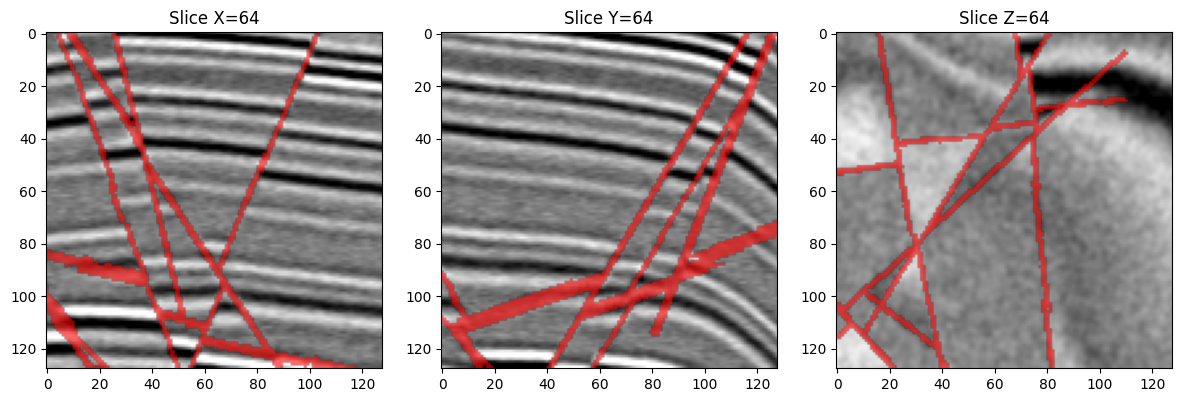

In [18]:
images, masks = next(iter(trainLoader))
img = images[0].squeeze().cpu().numpy()
msk = masks[0].squeeze().cpu().numpy()

print('xTrain Shape: ', img.shape)
print('yTrain Shape: ', msk.shape)
print('xTrain Range: ', (float(np.min(img)), float(np.max(img))))
print('yTrain Unique:', np.unique(msk).astype(int))

showTile(img)
showTile(img=img, mask=msk)

# TREINAMENTO

### Losses

In [19]:
from Losses.index import Losses
from EarlyStopping.index import EarlyStopping
from EMA.index import ModelEMA
from torch import amp
gc.collect()

19130

In [20]:
selected_loss = OPTIONS.get('loss')
loss = Losses(selected_loss, multiclass=network.multiclass)
loss

SmoothDiceLoss()

### Scheduler

In [21]:
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [22]:
class Scheduler:
    def __new__(cls, selected, optimizer):
        if selected == 'plateau':
            return ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
        
        if selected == 'cosine':
            return CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)
        
        return None


scheduler = OPTIONS.get('scheduler')
Scheduler(scheduler, network.optimizer)

### Trainer

In [23]:
class Trainer:
    def __init__(self, network, loss, epochs, scheduler='plateau', ema=False):
        self.network  = network
        self.loss     = loss
        self.epochs   = epochs
        self.img_size = network.img_size 
        
        self.scheduler = Scheduler(scheduler, self.network.optimizer)
        self.early_stopping = EarlyStopping(patience=15, mode='max', min_delta=1e-4)

        self.use_amp = False 
        self.scaler  = amp.GradScaler('cuda', enabled=self.use_amp)

        # COM EMA A VALIDACAO, O EARLY STOPPING E O TESTE USAM A MEDIA DOS PESOS, NAO O MODELO VIVO
        self.ema = ModelEMA(network.model, decay=0.999) if ema else None

    @property
    def model(self):
        return self.ema.model if self.ema else self.network.model

    def start(self):
        self.history = []
        
        for epoch in range(1, self.epochs + 1):
            train_loss, train_iou = self.train()
            val_loss, val_iou     = self.evaluate()

            self.history.append({
                'epoch': epoch,
                'train_loss': train_loss, 'val_loss': val_loss,
                'train_iou': train_iou, 'val_iou': val_iou,
                'lr': self.network.optimizer.param_groups[0]['lr'],
            })
            
            self.scheduler.step(val_loss)
            print(self.history[-1])

            with open(f'progress.json', 'w', encoding='utf-8') as file:
                json.dump(self.history[-1], file, ensure_ascii=False, indent=4)
            
            if self.early_stopping.ready(self.model, val_iou):
                break
            
        # O MELHOR ESTADO (DO EMA, SE LIGADO) VAI PARA O MODELO VIVO, QUE E O QUE SE SALVA E PLOTA
        self.early_stopping.restore_best(self.network.model)
        if self.ema:
            self.ema.model.load_state_dict(self.network.model.state_dict())

    # PERDA DA ITERACAO: A REDE PODE TER UM TERMO PROPRIO (A FAULT-SEG-NET SOMA O DO MSR, EQ. 12 DO ARTIGO)
    # O TERMO VEM DO MODELO QUE FEZ O FORWARD (O VIVO NO TREINO, O EMA NA AVALIACAO)
    def criterion(self, model, logits, masks):
        loss = self.loss(logits, masks)
        return model.compose(loss) if hasattr(model, 'compose') else loss

    def train(self, loader=trainLoader):
        self.network.model.train()
        self.network.iou.reset()
        train_loss = 0.0

        for (imgs, masks) in loader:
            imgs, masks = imgs.to(self.network.device), masks.to(self.network.device)
            self.network.optimizer.zero_grad()

            # calcular loss
            with amp.autocast('cuda', enabled=self.use_amp):
                logits = self.network.model(imgs)
                loss = self.criterion(self.network.model, logits, masks)
            
            train_loss += loss.item()
            self.scaler.scale(loss).backward()

            self.scaler.unscale_(self.network.optimizer)
            torch.nn.utils.clip_grad_norm_(self.network.model.parameters(), max_norm=1.0)

            self.scaler.step(self.network.optimizer)
            self.scaler.update()

            if self.ema:
                self.ema.update(self.network.model)
            
            # calcular iou
            if self.network.multiclass:
                preds  = torch.argmax(logits, dim=1) 
                target = masks.squeeze(1) if masks.dim() == 5 else masks
                self.network.iou.update(preds, target) 
            else:
                preds = (torch.sigmoid(logits) > 0.5)
                self.network.iou.update(preds, masks.int()) 
        
        # finalizar
        train_loss /= len(loader)
        train_iou  = self.network.iou.compute().item()
        return (train_loss, train_iou)

    def evaluate(self, loader=valLoader):
        self.model.eval()
        self.network.iou.reset()
        val_loss = 0.0

        with torch.no_grad():
            for (imgs, masks) in loader:
                imgs, masks = imgs.to(self.network.device), masks.to(self.network.device)

                with amp.autocast('cuda', enabled=self.use_amp):
                    logits = self.model(imgs)
                    val_loss += self.criterion(self.model, logits, masks).item()
                
                if self.network.multiclass:
                    preds  = torch.argmax(logits, dim=1)
                    target = masks.squeeze(1) if masks.dim() == 5 else masks
                    self.network.iou.update(preds, target)
                else:
                    preds = (torch.sigmoid(logits) > 0.5)
                    self.network.iou.update(preds, masks.int())
        
        val_loss /= len(loader)
        val_iou  = self.network.iou.compute().item()
        return (val_loss, val_iou)


EMA    = bool(OPTIONS.get('ema', False))
EPOCHS = OPTIONS.get('epochs', 100)

trainer = Trainer(network, loss, epochs=EPOCHS, scheduler=scheduler, ema=EMA)
trainer.start()

{'epoch': 1, 'train_loss': 0.8169074267148971, 'val_loss': 0.8090530157089233, 'train_iou': 0.10837488621473312, 'val_iou': 0.11642998456954956, 'lr': 0.001}


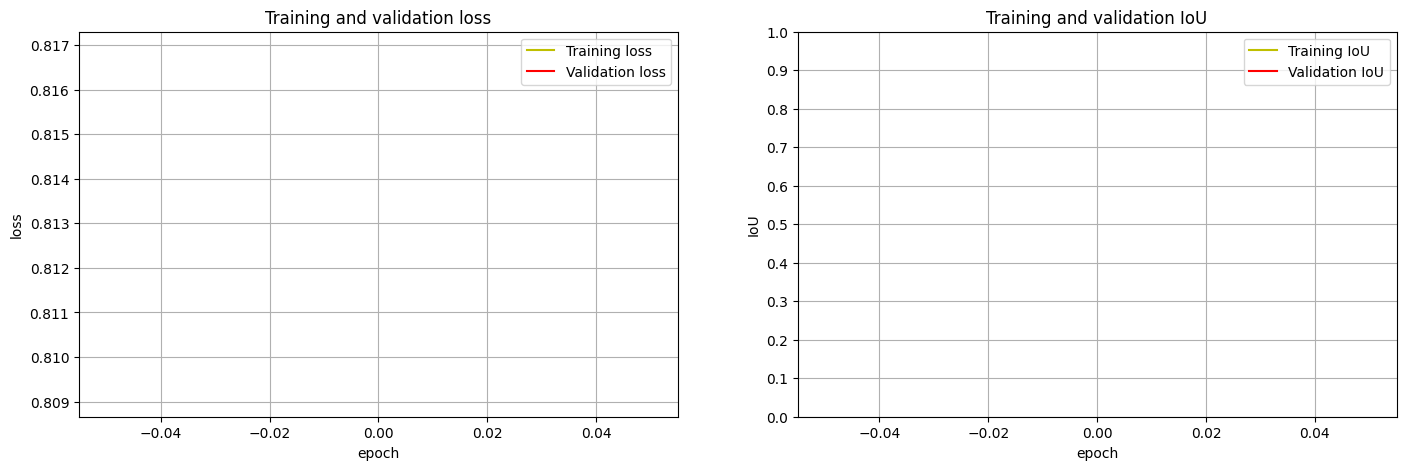

In [24]:
def plotModel(history, save=None):
    plt.figure(figsize=(17, 5))
    plt.subplot(1, 2, 1)
    plt.plot([h.get('train_loss') for h in history], 'y', label='Training loss')
    plt.plot([h.get('val_loss') for h in history], 'r', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('epoch'), plt.ylabel('loss')
    plt.legend(), plt.grid()

    plt.subplot(1, 2, 2)
    plt.plot([h.get('train_iou') for h in history], 'y', label='Training IoU')
    plt.plot([h.get('val_iou') for h in history], 'r', label='Validation IoU')
    plt.title('Training and validation IoU')
    plt.xlabel('epoch'), plt.ylabel('IoU')
    plt.legend(), plt.grid(), plt.gca().set_ylim(0, 1), plt.yticks([c/10 for c in range(11)])
    
    if not save:
        return plt.show()

    os.makedirs(os.path.dirname(save), exist_ok=True)
    plt.savefig(save, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()


plotModel(trainer.history)

# DADOS DE TESTE

In [25]:
test_loss, test_iou = trainer.evaluate(loader=testLoader)
test_iou

0.11769110709428787

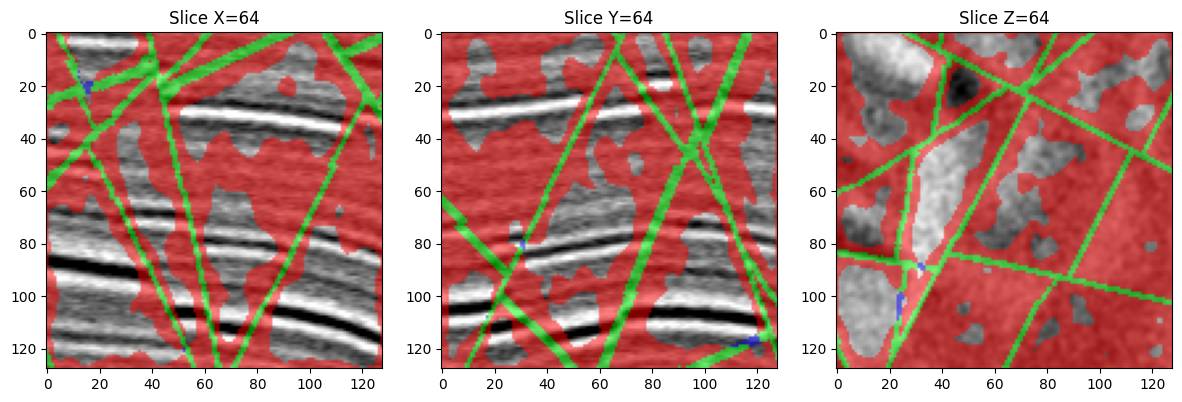

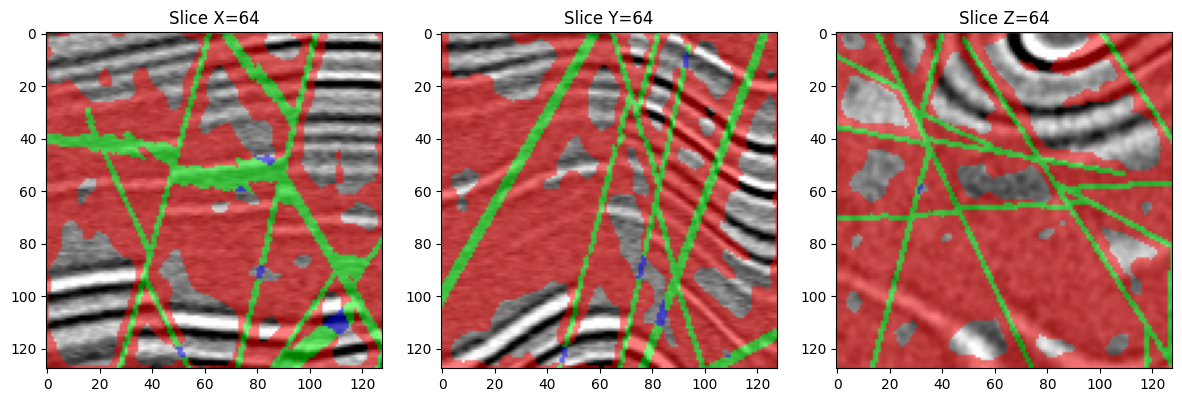

In [26]:
def plotPrediction(index, dataset=testDataset, network=network, alpha=0.5, savePath=None):
    img_tensor, mask_tensor = dataset[index]
    network.model.eval()

    with torch.no_grad():
        img_batch = img_tensor.unsqueeze(0).to(network.device)
        logits = network.model(img_batch)
        pred = torch.argmax(logits, dim=1).squeeze() if network.multiclass else (torch.sigmoid(logits) > 0.5).squeeze().int()

    img_np  = img_tensor.squeeze().cpu().numpy()
    mask_np = mask_tensor.squeeze().cpu().numpy()
    pred_np = pred.cpu().numpy()

    imgNorm = cv2.normalize(img_np, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    imgRgb  = np.stack((imgNorm, imgNorm, imgNorm), axis=-1)
    overlay = imgRgb.copy()
    is_gt   = (mask_np > 0)
    is_pred = (pred_np > 0)
    
    inters = (is_gt & is_pred)   # Acertos / Interseção
    overlay[is_gt]   = [0, 0, 255]  # Azul para o Ground Truth (Falhas reais não detectadas)
    overlay[is_pred] = [255, 0, 0]  # Vermelho para a Predição (Falsos alarmes)
    overlay[inters]  = [0, 255, 0]  # verde onde Predição e GT convergem (Acertos)

    result = (imgRgb * (1 - alpha) + overlay * alpha).astype(np.uint8)
    showTile(img=result, save=savePath)


for i in range(min(len(testDataset), 2)):
    plotPrediction(index=i, dataset=testDataset, network=network)

# SALVANDO O MODELO

In [27]:
from datetime import datetime
import json, inspect

In [28]:
os.makedirs('Backup/', exist_ok=True)
files   = [f for f in os.listdir('Backup/') if f.startswith('model_')]
indexes = sorted([int(path.split('_')[-1]) for path in files]) if len(files) > 0 else [0]
index   = indexes[-1] + 1
folder  = f'Backup/model_{index}'
os.makedirs(folder, exist_ok=True)
folder

'Backup/model_7'

In [29]:
iouData = getClasses(network, testLoader, save=os.path.join(folder, 'classes.png')) if network.multiclass else {'mean': test_iou}
path    = os.path.join(folder, 'predictions')
os.makedirs(path, exist_ok=True)

for i in range(min(len(testDataset), 20)):
    plotPrediction(index=i, dataset=testDataset, network=network, savePath=os.path.join(path, f'pred_{i}.png'))

In [30]:
model_info = {
    'trainer': {
        'path': f'model_{index}',
        'loss': selected_loss,
        'scheduler': scheduler,
        'epochs': trainer.epochs,
        'batch_size': OPTIONS.get('batch_size'),
        'ema': EMA,
        'trial': TRIAL,
        'val_iou':  trainer.early_stopping.best,
        'test_iou': test_iou
    },
    'processing': OPTIONS,
    'model': model_options,
    'iou': iouData
}

model_data = {
    'model': network.model.state_dict(),
    'optimizer': network.optimizer.state_dict(),
    'timestamp': datetime.now().strftime('%d/%m/%y %H:%M:%S'), 
    'history': trainer.history,
}

with open(f'{folder}/info.json', 'w', encoding='utf-8') as file:
    json.dump(model_info, file, ensure_ascii=False, indent=4)   

plotModel(model_data['history'], save=os.path.join(folder, 'train.png'))
torch.save(model_data, f'{folder}/model.pth')
print('model saved in', folder)

model saved in Backup/model_7
